# Global Supply Chain Risk & Disruption Analysis (2024–2025)

**Dataset:** `global_supply_chain_risk_2026 (3).csv` — 5,000 shipments, 14 columns

**Objective:**
1. Understand what drives supply chain disruptions (`Disruption_Occurred`)
2. Build the same composite **Risk Exposure Score** used in SQL Server, so numbers match across tools
3. Train a predictive model that flags high-risk shipments *before* they ship

**Structure**
1. Load & inspect data
2. Data quality checks
3. Exploratory data analysis (EDA)
4. Risk Exposure Score (same formula as SQL Step 3)
5. Visualizations
6. Predictive model: will this shipment be disrupted?
7. Export scored dataset (for Power BI)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('global_supply_chain_risk_2026 (3).csv', parse_dates=['Date'])
df.rename(columns={'Date': 'Ship_Date'}, inplace=True)
df.head()


,Shipment_ID,Ship_Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [3]:
# --- OPTIONAL: load directly from SQL Server instead of the CSV ---
# import sqlalchemy
# conn_str = (
#     "mssql+pyodbc://localhost/SupplyChainRisk?"
#     "driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
# )
# engine = sqlalchemy.create_engine(conn_str)
# df = pd.read_sql("SELECT * FROM dbo.vw_Shipments_Master", engine)


In [4]:
print(df.shape)
df.info()


(5000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Shipment_ID                5000 non-null   str           
 1   Ship_Date                  5000 non-null   datetime64[us]
 2   Origin_Port                5000 non-null   str           
 3   Destination_Port           5000 non-null   str           
 4   Transport_Mode             5000 non-null   str           
 5   Product_Category           5000 non-null   str           
 6   Distance_km                5000 non-null   float64       
 7   Weight_MT                  5000 non-null   float64       
 8   Fuel_Price_Index           5000 non-null   float64       
 9   Geopolitical_Risk_Score    5000 non-null   float64       
 10  Weather_Condition          5000 non-null   str           
 11  Carrier_Reliability_Score  5000 non-null   float64       
 12  Lead_T

## 2. Data Quality Checks

In [5]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate Shipment_IDs:", df['Shipment_ID'].duplicated().sum())
print("\nDate range:", df['Ship_Date'].min(), "to", df['Ship_Date'].max())
print("\nOverall disruption rate: {:.1%}".format(df['Disruption_Occurred'].mean()))
df.describe()


Missing values:
 Shipment_ID                  0
Ship_Date                    0
Origin_Port                  0
Destination_Port             0
Transport_Mode               0
Product_Category             0
Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Weather_Condition            0
Carrier_Reliability_Score    0
Lead_Time_Days               0
Disruption_Occurred          0
dtype: int64

Duplicate Shipment_IDs: 0

Date range: 2024-01-01 00:00:00 to 2025-12-31 00:00:00

Overall disruption rate: 61.3%


,Ship_Date,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2025-01-04 20:34:04.800000,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600
min,2024-01-01 00:00:00,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000
25%,2024-07-03 00:00:00,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000
50%,2025-01-06 00:00:00,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000
75%,2025-07-09 00:00:00,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000
max,2025-12-31 00:00:00,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000
std,NaN,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205


In [6]:
for col in ['Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Weather_Condition']:
    print(col, '->', sorted(df[col].unique()))


Origin_Port -> ['Antwerp', 'Busan', 'Dubai', 'Hamburg', 'Los Angeles', 'Rotterdam', 'Shanghai', 'Singapore']
Destination_Port -> ['Antwerp', 'Busan', 'Dubai', 'Hamburg', 'Los Angeles', 'Marseille', 'Rotterdam', 'Shanghai', 'Singapore']
Transport_Mode -> ['Air', 'Rail', 'Road', 'Sea']
Product_Category -> ['Automotive', 'Electronics', 'Perishables', 'Pharmaceuticals', 'Textiles']
Weather_Condition -> ['Clear', 'Fog', 'Hurricane', 'Rain', 'Storm']


## 3. Exploratory Data Analysis

### 3.1 Disruption rate by transport mode

In [7]:
mode_summary = (df.groupby('Transport_Mode')
                  .agg(Shipments=('Shipment_ID','count'),
                       Disruption_Rate=('Disruption_Occurred','mean'),
                       Avg_Geo_Risk=('Geopolitical_Risk_Score','mean'),
                       Avg_Reliability=('Carrier_Reliability_Score','mean'))
                  .round(3)
                  .sort_values('Disruption_Rate', ascending=False))
mode_summary


,Shipments,Disruption_Rate,Avg_Geo_Risk,Avg_Reliability
Transport_Mode,,,,
Air,1320,0.617,4.986,0.753
Rail,1185,0.612,5.165,0.763
Road,1214,0.610,5.100,0.751
Sea,1281,0.610,5.067,0.752


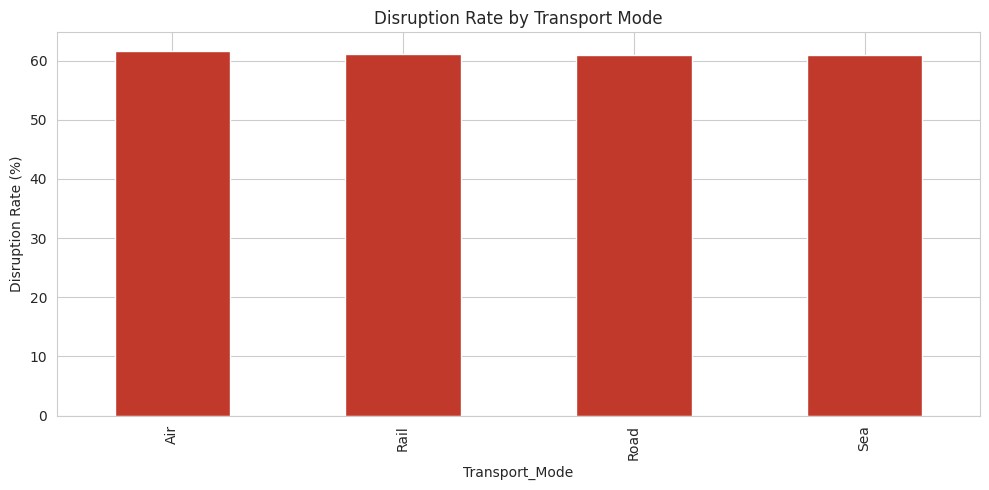

In [8]:
fig, ax = plt.subplots()
(mode_summary['Disruption_Rate']*100).plot(kind='bar', ax=ax, color='#c0392b')
ax.set_title('Disruption Rate by Transport Mode')
ax.set_ylabel('Disruption Rate (%)')
plt.tight_layout()
plt.show()


### 3.2 Disruption rate by weather condition

In [9]:
weather_summary = (df.groupby('Weather_Condition')
                     .agg(Shipments=('Shipment_ID','count'),
                          Disruption_Rate=('Disruption_Occurred','mean'),
                          Avg_Lead_Time=('Lead_Time_Days','mean'))
                     .round(3)
                     .sort_values('Disruption_Rate', ascending=False))
weather_summary


,Shipments,Disruption_Rate,Avg_Lead_Time
Weather_Condition,,,
Hurricane,990,1.000,53.502
Storm,1002,0.795,19.299
Fog,1036,0.481,9.893
Rain,977,0.420,7.736
Clear,995,0.370,6.699


/tmp/ipykernel_584/4046404175.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weather_summary.index, y=weather_summary['Disruption_Rate']*100, ax=ax, palette='Blues_r')


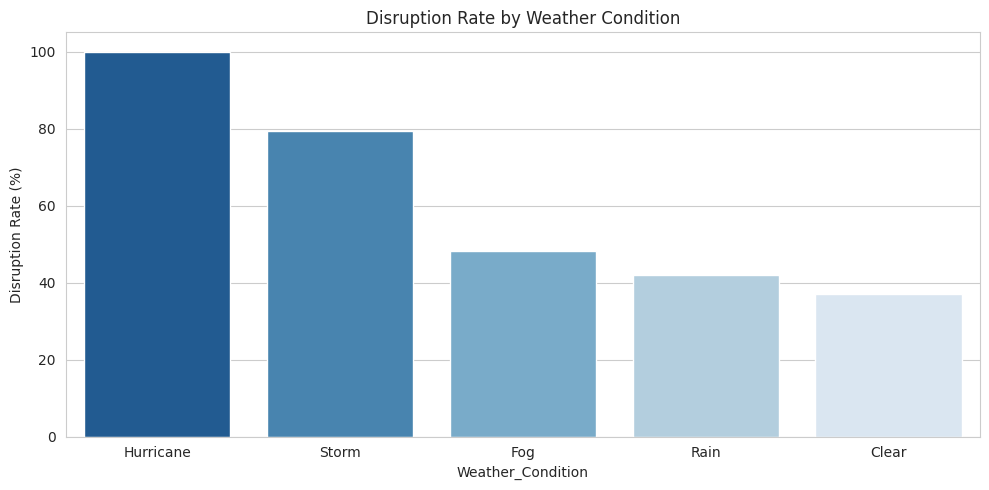

In [10]:
fig, ax = plt.subplots()
sns.barplot(x=weather_summary.index, y=weather_summary['Disruption_Rate']*100, ax=ax, palette='Blues_r')
ax.set_title('Disruption Rate by Weather Condition')
ax.set_ylabel('Disruption Rate (%)')
plt.tight_layout()
plt.show()


### 3.3 Carrier reliability vs disruption

In [11]:
df['Reliability_Bucket'] = pd.cut(df['Carrier_Reliability_Score'],
                                    bins=[0, 0.65, 0.85, 1.0],
                                    labels=['Low (<0.65)', 'Medium (0.65-0.85)', 'High (>=0.85)'])
rel_summary = df.groupby('Reliability_Bucket')['Disruption_Occurred'].mean().round(3) * 100
rel_summary


Reliability_Bucket
Low (<0.65)           65.3
Medium (0.65-0.85)    62.3
High (>=0.85)         56.1
Name: Disruption_Occurred, dtype: float64

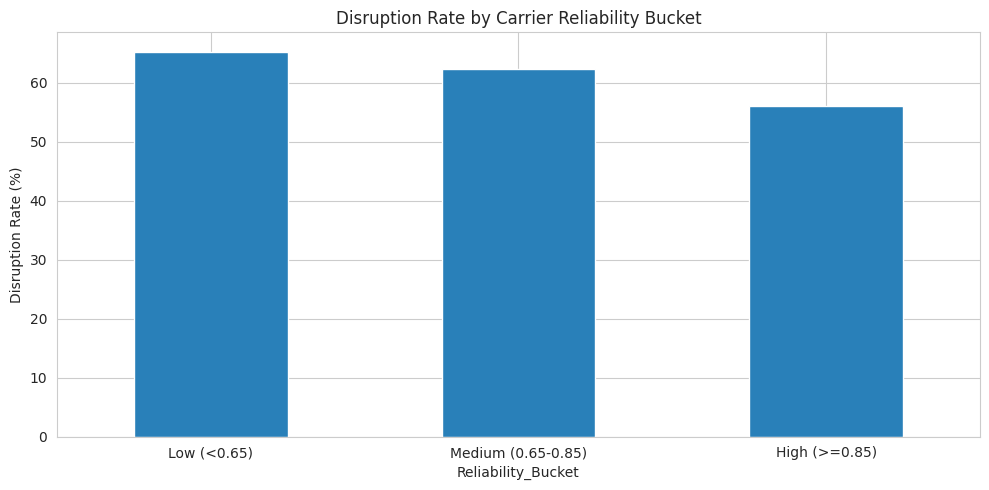

In [12]:
fig, ax = plt.subplots()
rel_summary.plot(kind='bar', color='#2980b9', ax=ax)
ax.set_title('Disruption Rate by Carrier Reliability Bucket')
ax.set_ylabel('Disruption Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 3.4 Highest-risk trade routes

In [13]:
df['Route'] = df['Origin_Port'] + ' -> ' + df['Destination_Port']
route_summary = (df.groupby('Route')
                    .agg(Shipments=('Shipment_ID','count'),
                         Disruption_Rate=('Disruption_Occurred','mean'),
                         Avg_Geo_Risk=('Geopolitical_Risk_Score','mean'))
                    .round(3)
                    .sort_values('Disruption_Rate', ascending=False))
route_summary.head(15)


,Shipments,Disruption_Rate,Avg_Geo_Risk
Route,,,
Rotterdam -> Marseille,68,0.750,4.800
Los Angeles -> Singapore,68,0.721,5.234
Hamburg -> Rotterdam,72,0.708,4.949
Rotterdam -> Busan,86,0.686,5.365
Singapore -> Antwerp,72,0.681,5.146
Busan -> Shanghai,91,0.681,5.027
Busan -> Marseille,65,0.677,5.391
Shanghai -> Singapore,62,0.677,5.173
Hamburg -> Los Angeles,85,0.671,5.119


/tmp/ipykernel_584/2693060314.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_routes.index, x=top_routes['Disruption_Rate']*100, ax=ax, palette='OrRd_r')


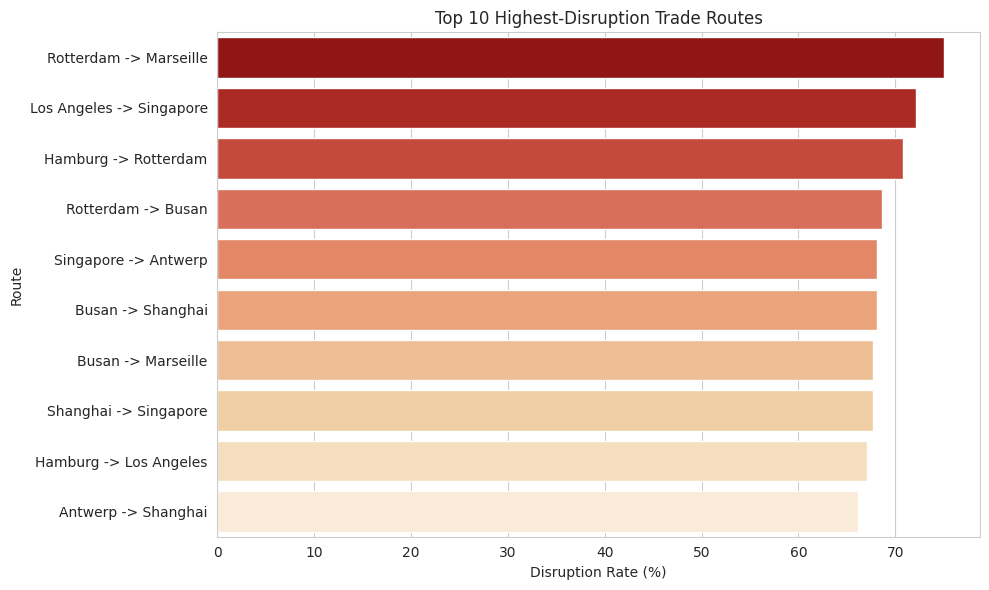

In [14]:
top_routes = route_summary.head(10)
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(y=top_routes.index, x=top_routes['Disruption_Rate']*100, ax=ax, palette='OrRd_r')
ax.set_title('Top 10 Highest-Disruption Trade Routes')
ax.set_xlabel('Disruption Rate (%)')
plt.tight_layout()
plt.show()


### 3.5 Monthly trend: disruption rate & fuel price

In [15]:
monthly = (df.set_index('Ship_Date')
             .resample('MS')
             .agg(Disruption_Rate=('Disruption_Occurred','mean'),
                  Avg_Fuel=('Fuel_Price_Index','mean'),
                  Shipments=('Shipment_ID','count'))
             .round(3))
monthly.head()


,Disruption_Rate,Avg_Fuel,Shipments
Ship_Date,,,
2024-01-01,0.636,2.780,173
2024-02-01,0.564,2.815,195
2024-03-01,0.568,2.908,220
2024-04-01,0.624,2.878,229
2024-05-01,0.626,2.924,211


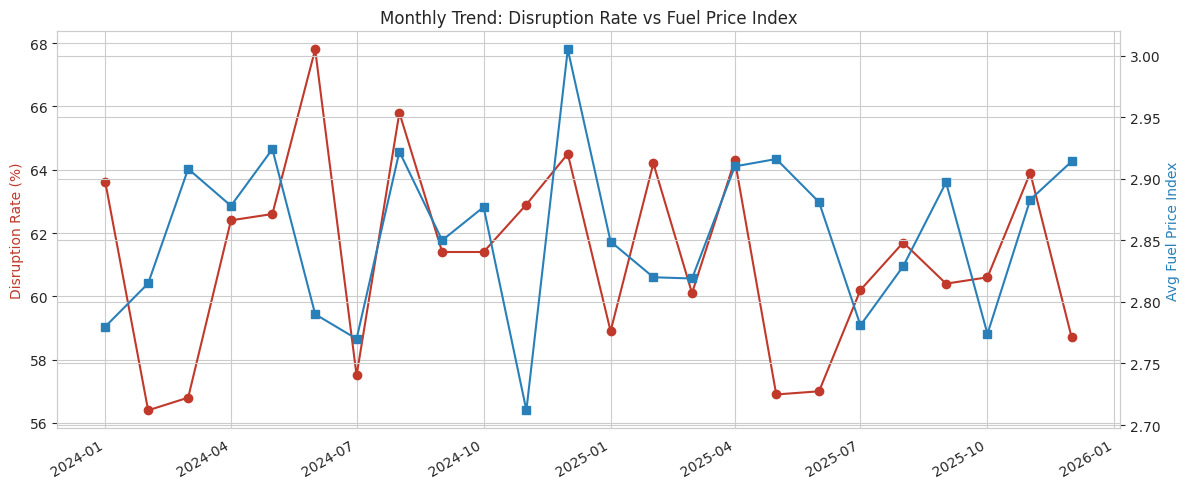

In [16]:
fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(monthly.index, monthly['Disruption_Rate']*100, color='#c0392b', marker='o', label='Disruption Rate (%)')
ax1.set_ylabel('Disruption Rate (%)', color='#c0392b')
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['Avg_Fuel'], color='#2980b9', marker='s', label='Avg Fuel Index')
ax2.set_ylabel('Avg Fuel Price Index', color='#2980b9')
ax1.set_title('Monthly Trend: Disruption Rate vs Fuel Price Index')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### 3.6 Correlation matrix (numeric features)

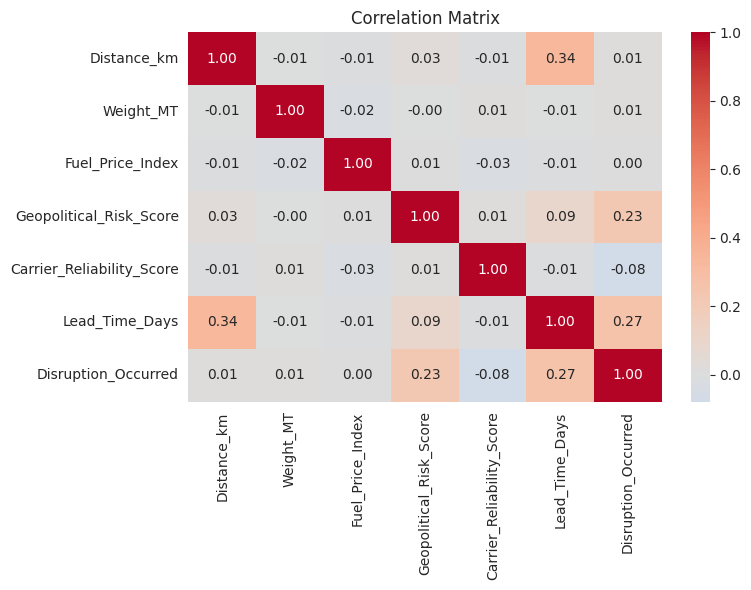

In [17]:
numeric_cols = ['Distance_km','Weight_MT','Fuel_Price_Index','Geopolitical_Risk_Score',
                'Carrier_Reliability_Score','Lead_Time_Days','Disruption_Occurred']
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()


## 4. Risk Exposure Score

Same weighted formula as the SQL Server script (`03_risk_score_and_views.sql`):

```
Risk_Exposure_Score = 0.5 * Geopolitical_Risk_Score
                     + 0.3 * normalized(Fuel_Price_Index)
                     + 0.2 * normalized(Distance_km)
```


In [18]:
def minmax_10(s):
    return (s - s.min()) / (s.max() - s.min()) * 10

df['Fuel_norm'] = minmax_10(df['Fuel_Price_Index'])
df['Distance_norm'] = minmax_10(df['Distance_km'])

df['Risk_Exposure_Score'] = (
    0.5 * df['Geopolitical_Risk_Score']
    + 0.3 * df['Fuel_norm']
    + 0.2 * df['Distance_norm']
).round(2)

df['Risk_Tier'] = pd.cut(
    df['Risk_Exposure_Score'],
    bins=[-0.01, 4, 7, 10],
    labels=['Low', 'Medium', 'High']
)

df[['Shipment_ID','Risk_Exposure_Score','Risk_Tier','Disruption_Occurred']].head()


,Shipment_ID,Risk_Exposure_Score,Risk_Tier,Disruption_Occurred
0,SC-10000,4.37,Medium,1
1,SC-10001,6.65,Medium,1
2,SC-10002,4.79,Medium,0
3,SC-10003,3.42,Low,1
4,SC-10004,2.69,Low,1


In [19]:
tier_disruption = df.groupby('Risk_Tier')['Disruption_Occurred'].agg(['count','mean']).round(3)
tier_disruption.columns = ['Shipments','Disruption_Rate']
tier_disruption


,Shipments,Disruption_Rate
Risk_Tier,,
Low,1453,0.498
Medium,2816,0.642
High,731,0.729


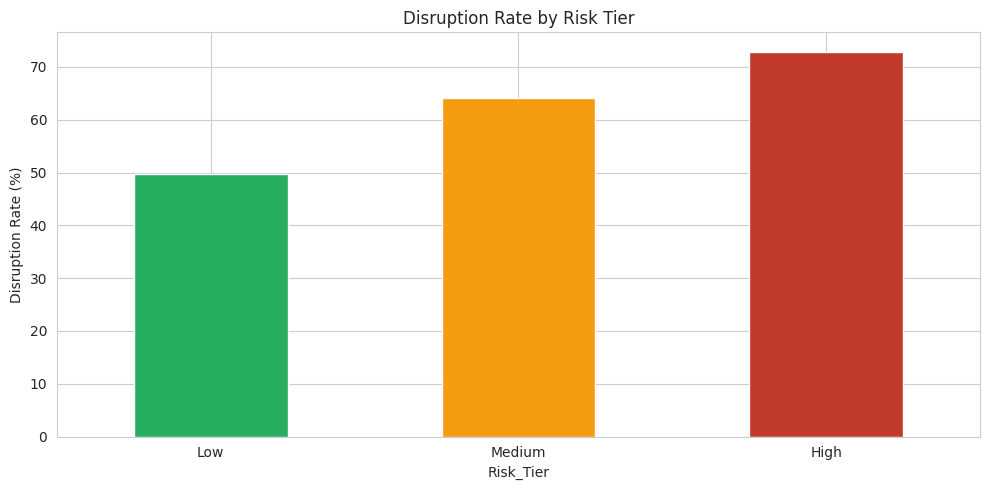

In [20]:
fig, ax = plt.subplots()
(tier_disruption['Disruption_Rate']*100).plot(kind='bar', color=['#27ae60','#f39c12','#c0392b'], ax=ax)
ax.set_title('Disruption Rate by Risk Tier')
ax.set_ylabel('Disruption Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Predictive Model: Will This Shipment Be Disrupted?

We'll train a classifier on shipment-level features known *before* the shipment happens
(distance, mode, category, weather, fuel index, geopolitical risk, carrier reliability)
to predict `Disruption_Occurred`. This is the centerpiece of a "high demand" portfolio
project — descriptive analysis explains the past, this predicts the future.


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

feature_cols = ['Transport_Mode','Product_Category','Weather_Condition',
                'Distance_km','Weight_MT','Fuel_Price_Index',
                'Geopolitical_Risk_Score','Carrier_Reliability_Score','Lead_Time_Days']
target_col = 'Disruption_Occurred'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

categorical_features = ['Transport_Mode','Product_Category','Weather_Condition']
numeric_features = ['Distance_km','Weight_MT','Fuel_Price_Index',
                     'Geopolitical_Risk_Score','Carrier_Reliability_Score','Lead_Time_Days']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


### 5.1 Logistic Regression (interpretable baseline)

In [22]:
logreg_pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
logreg_pipe.fit(X_train, y_train)

y_pred_lr = logreg_pipe.predict(X_test)
y_proba_lr = logreg_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba_lr), 3))


              precision    recall  f1-score   support

           0       0.66      0.63      0.65       387
           1       0.77      0.79      0.78       613

    accuracy                           0.73      1000
   macro avg       0.72      0.71      0.71      1000
weighted avg       0.73      0.73      0.73      1000

ROC AUC: 0.828


### 5.2 Random Forest (captures non-linear interactions)

In [23]:
rf_pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42))
])
rf_pipe.fit(X_train, y_train)

y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba_rf), 3))


              precision    recall  f1-score   support

           0       0.64      0.63      0.63       387
           1       0.77      0.78      0.77       613

    accuracy                           0.72      1000
   macro avg       0.70      0.70      0.70      1000
weighted avg       0.72      0.72      0.72      1000

ROC AUC: 0.816


### 5.3 Compare ROC curves

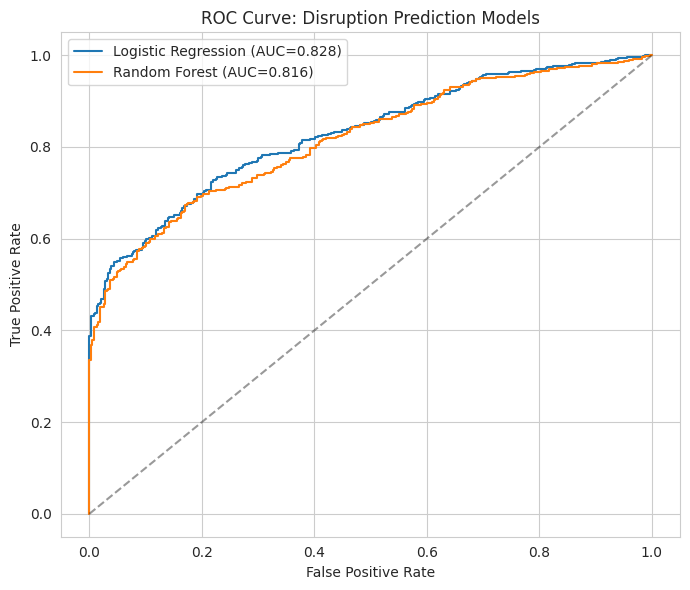

In [24]:
fig, ax = plt.subplots(figsize=(7,6))
for name, proba in [('Logistic Regression', y_proba_lr), ('Random Forest', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Disruption Prediction Models')
ax.legend()
plt.tight_layout()
plt.show()


### 5.4 Confusion matrix (Random Forest)

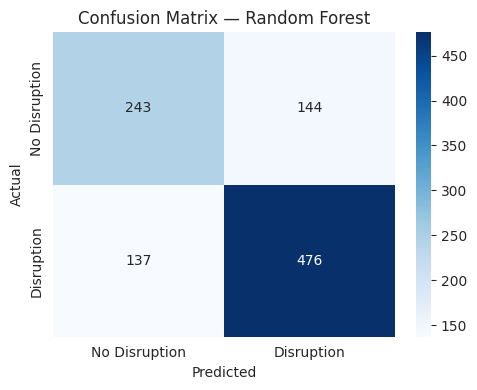

In [25]:
cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disruption','Disruption'],
            yticklabels=['No Disruption','Disruption'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()


### 5.5 What actually drives disruption risk? (Feature importance)

/tmp/ipykernel_584/3100720449.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=fi.index, x=fi.values, ax=ax, palette='viridis')


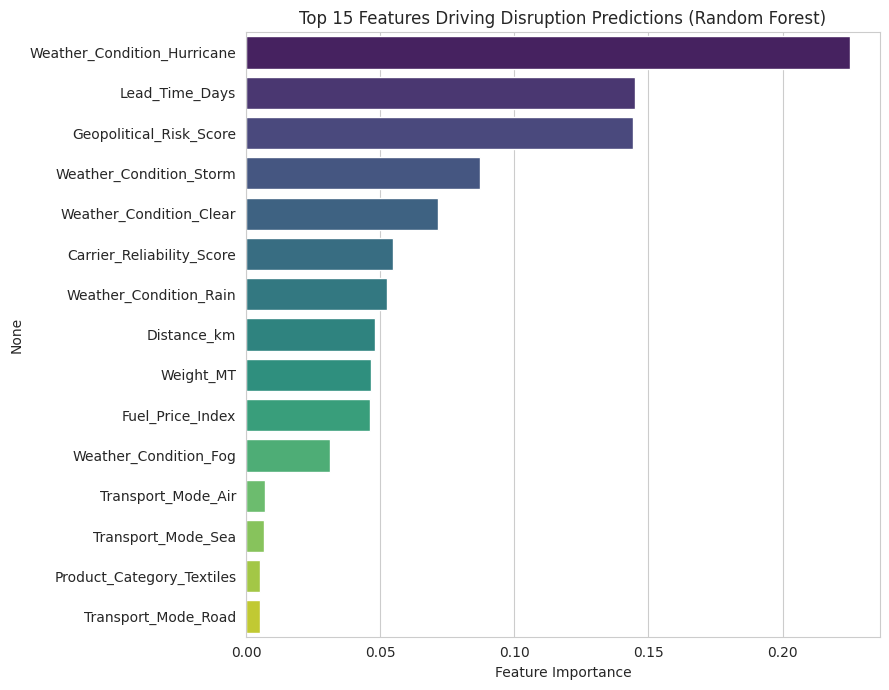

In [26]:
feature_names = (numeric_features +
                  list(rf_pipe.named_steps['prep']
                       .named_transformers_['cat']
                       .get_feature_names_out(categorical_features)))
importances = rf_pipe.named_steps['model'].feature_importances_

fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9,7))
sns.barplot(y=fi.index, x=fi.values, ax=ax, palette='viridis')
ax.set_title('Top 15 Features Driving Disruption Predictions (Random Forest)')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.show()


## 6. Export Scored Dataset (for Power BI / further use)

In [27]:
df['Disruption_Risk_Probability'] = rf_pipe.predict_proba(df[feature_cols])[:, 1].round(3)

export_cols = ['Shipment_ID','Ship_Date','Origin_Port','Destination_Port','Route',
               'Transport_Mode','Product_Category','Weather_Condition',
               'Distance_km','Weight_MT','Fuel_Price_Index','Geopolitical_Risk_Score',
               'Carrier_Reliability_Score','Lead_Time_Days','Disruption_Occurred',
               'Risk_Exposure_Score','Risk_Tier','Disruption_Risk_Probability']
df[export_cols].to_csv('shipments_scored.csv', index=False)
print("Exported shipments_scored.csv:", df.shape[0], "rows")


Exported shipments_scored.csv: 5000 rows


## Next steps
- Load `shipments_scored.csv` (or the SQL views) into Power BI for interactive dashboards.
- The `Disruption_Risk_Probability` column lets you build a "shipments to watch" view —
  filter for high predicted risk *before* they're disrupted.
- Consider adding a cost-of-disruption estimate (e.g. Weight_MT × a $/MT penalty) to turn
  this into a dollar-impact dashboard, which resonates strongly with business stakeholders.
